# 🔴 Dataset Masivo de Pokémon desde PokéAPI

Este notebook descarga datos completos de todos los Pokémon disponibles en la **PokéAPI**.
Incluye estadísticas, tipos, habilidades, evoluciones y más.

## 1. Instalación de librerías

In [4]:
# !pip install requests pandas tqdm matplotlib seaborn numpy
import requests
import pandas as pd
import json
from tqdm import tqdm
import time
import numpy as np

## 2. Obtener listado de todos los Pokémon

In [5]:
# Primero obtenemos cuántos Pokémon hay en total
url_pokemon_list = "https://pokeapi.co/api/v2/pokemon?limit=10000"

print("🔄 Descargando listado de Pokémon...")
r = requests.get(url_pokemon_list)
pokemon_list = r.json()

total_pokemon = pokemon_list['count']
print(f"✅ Total de Pokémon disponibles: {total_pokemon}")

# Extraer URLs de cada Pokémon
pokemon_urls = [p['url'] for p in pokemon_list['results']]
print(f"📊 URLs extraídas: {len(pokemon_urls)}")

🔄 Descargando listado de Pokémon...
✅ Total de Pokémon disponibles: 1350
📊 URLs extraídas: 1350


## 3. Descargar datos detallados de cada Pokémon

In [6]:
pokemon_data = []

print("\n🔴 Descargando datos detallados de cada Pokémon...\n")

for url in tqdm(pokemon_urls, desc="Pokémon", total=len(pokemon_urls)):
    try:
        r = requests.get(url, timeout=5)
        data = r.json()
        
        # Extraer información clave
        pokemon_info = {
            'id': data['id'],
            'nombre': data['name'].capitalize(),
            'altura': data['height'] / 10,  # convertir a metros
            'peso': data['weight'] / 10,    # convertir a kg
            'experiencia_base': data.get('base_experience'),
            'es_predeterminado': data.get('is_main_series', True),  # Valor por defecto True
            'tipos': ','.join([t['type']['name'].capitalize() for t in data['types']]),
            'habilidades': ','.join([a['ability']['name'].capitalize() for a in data['abilities']]),
            'hp': next((s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'hp'), None),
            'ataque': next((s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'attack'), None),
            'defensa': next((s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'defense'), None),
            'ataque_especial': next((s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'special-attack'), None),
            'defensa_especial': next((s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'special-defense'), None),
            'velocidad': next((s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'speed'), None),
            'stat_total': sum([s['base_stat'] for s in data['stats']]),
            'url_sprite': data['sprites']['front_default'],
            'url_imagen_oficial': data['sprites']['other']['official-artwork']['front_default'] if 'official-artwork' in data['sprites']['other'] else None
        }
        pokemon_data.append(pokemon_info)
        
        # Pequeña pausa para no saturar la API
        time.sleep(0.01)
    except Exception as e:
        # Mostrar error pero continuar
        pass

print(f"\n✅ Datos descargados: {len(pokemon_data)} Pokémon")


🔴 Descargando datos detallados de cada Pokémon...



Pokémon: 100%|██████████| 1350/1350 [06:59<00:00,  3.22it/s]


✅ Datos descargados: 1350 Pokémon


## 4. Crear DataFrame y limpiar datos

In [7]:
df_pokemon = pd.DataFrame(pokemon_data)

# Mostrar información del dataset
print(f"📊 Forma del dataset: {df_pokemon.shape}")
print(f"\n📋 Primeros registros:")
display(df_pokemon.head(10))

print(f"\n📈 Información del dataset:")
print(df_pokemon.info())

print(f"\n🔢 Estadísticas numéricas:")
display(df_pokemon.describe())

📊 Forma del dataset: (1350, 17)

📋 Primeros registros:


,id,nombre,altura,peso,experiencia_base,es_predeterminado,tipos,habilidades,hp,ataque,defensa,ataque_especial,defensa_especial,velocidad,stat_total,url_sprite,url_imagen_oficial
0,1,Bulbasaur,0.7,6.9,64.0,True,"Grass,Poison","Overgrow,Chlorophyll",45,49,49,65,65,45,318,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,Ivysaur,1.0,13.0,142.0,True,"Grass,Poison","Overgrow,Chlorophyll",60,62,63,80,80,60,405,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
2,3,Venusaur,2.0,100.0,236.0,True,"Grass,Poison","Overgrow,Chlorophyll",80,82,83,100,100,80,525,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,Charmander,0.6,8.5,62.0,True,Fire,"Blaze,Solar-power",39,52,43,60,50,65,309,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
4,5,Charmeleon,1.1,19.0,142.0,True,Fire,"Blaze,Solar-power",58,64,58,80,65,80,405,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
5,6,Charizard,1.7,90.5,240.0,True,"Fire,Flying","Blaze,Solar-power",78,84,78,109,85,100,534,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
6,7,Squirtle,0.5,9.0,63.0,True,Water,"Torrent,Rain-dish",44,48,65,50,64,43,314,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
7,8,Wartortle,1.0,22.5,142.0,True,Water,"Torrent,Rain-dish",59,63,80,65,80,58,405,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
8,9,Blastoise,1.6,85.5,239.0,True,Water,"Torrent,Rain-dish",79,83,100,85,105,78,530,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...
9,10,Caterpie,0.3,2.9,39.0,True,Bug,"Shield-dust,Run-away",45,30,35,20,20,45,195,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...



📈 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1350 non-null   int64  
 1   nombre              1350 non-null   object 
 2   altura              1350 non-null   float64
 3   peso                1350 non-null   float64
 4   experiencia_base    1302 non-null   float64
 5   es_predeterminado   1350 non-null   bool   
 6   tipos               1350 non-null   object 
 7   habilidades         1350 non-null   object 
 8   hp                  1350 non-null   int64  
 9   ataque              1350 non-null   int64  
 10  defensa             1350 non-null   int64  
 11  ataque_especial     1350 non-null   int64  
 12  defensa_especial    1350 non-null   int64  
 13  velocidad           1350 non-null   int64  
 14  stat_total          1350 non-null   int64  
 15  url_sprite          1286 no

,id,altura,peso,experiencia_base,hp,ataque,defensa,ataque_especial,defensa_especial,velocidad,stat_total
count,1350.000000,1350.000000,1350.000000,1302.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000
mean,2836.148148,2.047704,99.171926,161.943932,71.671852,82.813333,76.194074,75.368148,74.095556,71.961481,452.104444
std,4135.531960,5.326540,195.368919,82.532554,26.837396,32.384126,30.724283,33.989075,27.801487,30.620661,122.507864
min,1.000000,0.100000,0.000000,36.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000
25%,338.250000,0.600000,9.425000,71.000000,55.000000,60.000000,55.000000,50.000000,54.000000,49.000000,340.000000
50%,675.500000,1.100000,32.700000,165.000000,70.000000,80.000000,70.000000,69.000000,70.000000,70.000000,475.000000
75%,1012.750000,1.700000,85.425000,222.500000,85.000000,103.000000,95.000000,97.000000,90.000000,94.750000,530.000000
max,10325.000000,100.000000,1000.000000,608.000000,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000,1125.000000


## 5. Análisis exploratorio básico

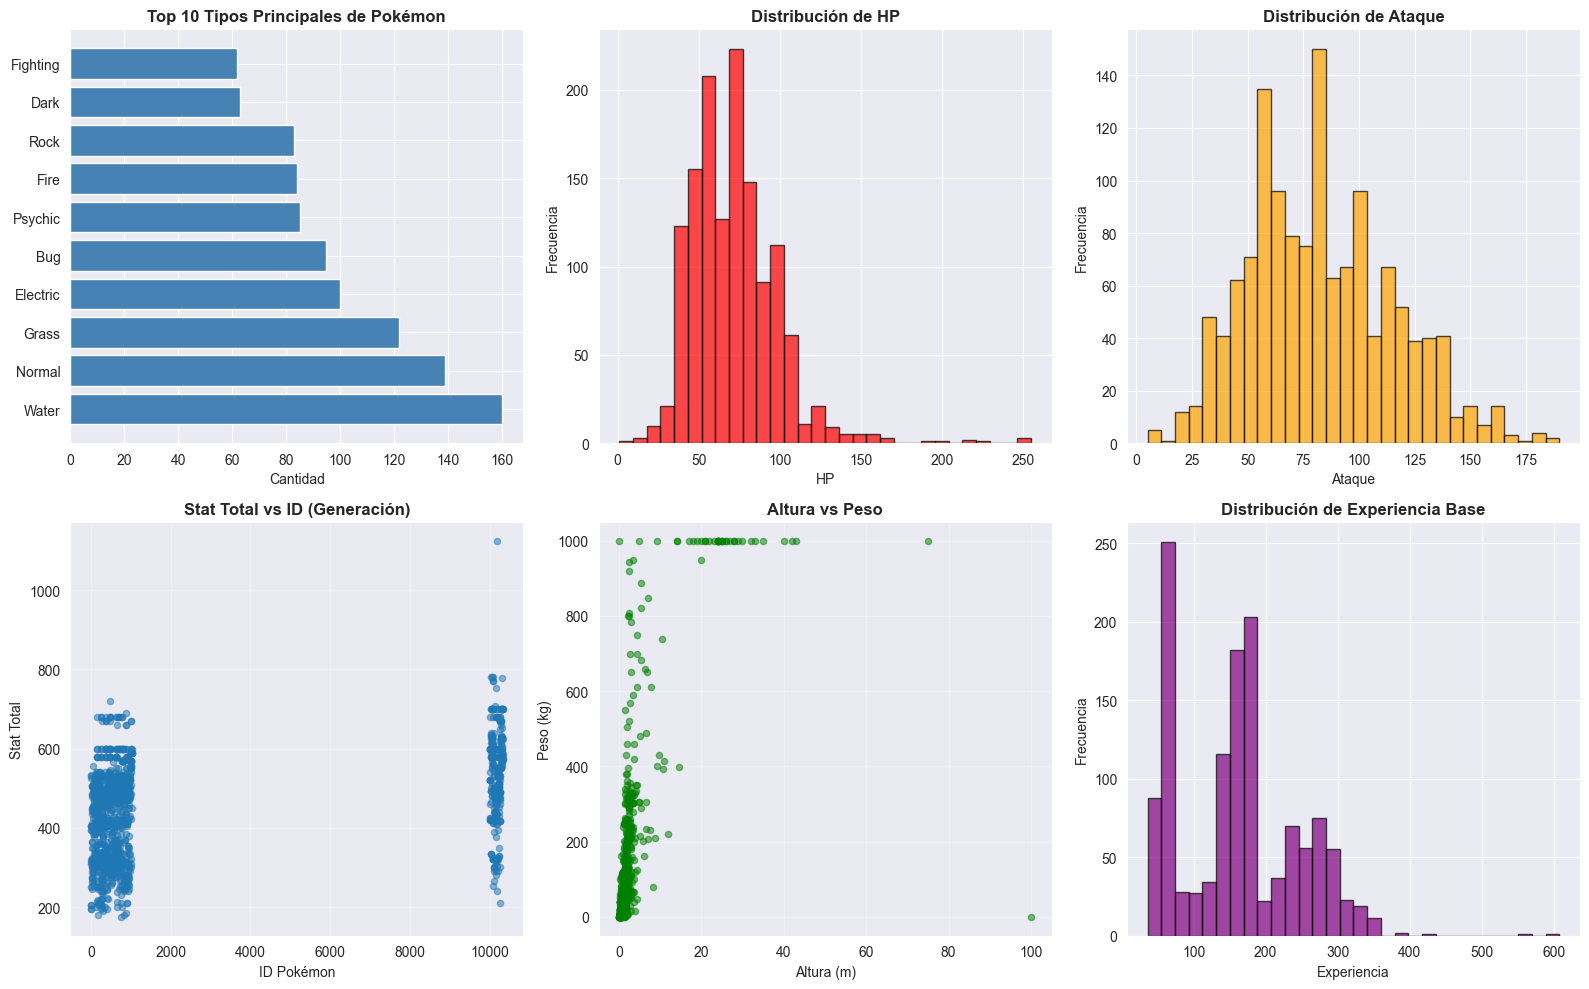

✅ Gráficos guardados como 'pokemon_eda_basico.png'


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)

# 1. Distribución de tipos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Tipos principales
tipos_main = df_pokemon['tipos'].str.split(',').str[0].value_counts().head(10)
axes[0, 0].barh(tipos_main.index, tipos_main.values, color='steelblue')
axes[0, 0].set_title('Top 10 Tipos Principales de Pokémon', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cantidad')

# Distribución de HP
axes[0, 1].hist(df_pokemon['hp'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribución de HP', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('HP')
axes[0, 1].set_ylabel('Frecuencia')

# Distribución de Ataque
axes[0, 2].hist(df_pokemon['ataque'], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Distribución de Ataque', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Ataque')
axes[0, 2].set_ylabel('Frecuencia')

# Stat Total vs ID
axes[1, 0].scatter(df_pokemon['id'], df_pokemon['stat_total'], alpha=0.5, s=20)
axes[1, 0].set_title('Stat Total vs ID (Generación)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('ID Pokémon')
axes[1, 0].set_ylabel('Stat Total')
axes[1, 0].grid(True, alpha=0.3)

# Altura vs Peso
axes[1, 1].scatter(df_pokemon['altura'], df_pokemon['peso'], alpha=0.5, s=20, color='green')
axes[1, 1].set_title('Altura vs Peso', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Altura (m)')
axes[1, 1].set_ylabel('Peso (kg)')
axes[1, 1].grid(True, alpha=0.3)

# Experiencia base
axes[1, 2].hist(df_pokemon['experiencia_base'].dropna(), bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Distribución de Experiencia Base', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Experiencia')
axes[1, 2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('pokemon_eda_basico.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficos guardados como 'pokemon_eda_basico.png'")

## 6. Estadísticas interesantes

In [9]:
print("🔍 ESTADÍSTICAS INTERESANTES\n")
print(f"Total de Pokémon: {len(df_pokemon)}")
print(f"\nPokémon con mayor HP: {df_pokemon.loc[df_pokemon['hp'].idxmax(), 'nombre']} ({df_pokemon['hp'].max()} HP)")
print(f"Pokémon con mayor Ataque: {df_pokemon.loc[df_pokemon['ataque'].idxmax(), 'nombre']} ({df_pokemon['ataque'].max()})")
print(f"Pokémon con mayor Defensa: {df_pokemon.loc[df_pokemon['defensa'].idxmax(), 'nombre']} ({df_pokemon['defensa'].max()})")
print(f"Pokémon con mayor Velocidad: {df_pokemon.loc[df_pokemon['velocidad'].idxmax(), 'nombre']} ({df_pokemon['velocidad'].max()})")
print(f"\nPokémon más ligero: {df_pokemon.loc[df_pokemon['peso'].idxmin(), 'nombre']} ({df_pokemon['peso'].min()} kg)")
print(f"Pokémon más pesado: {df_pokemon.loc[df_pokemon['peso'].idxmax(), 'nombre']} ({df_pokemon['peso'].max()} kg)")
print(f"\nPokémon más bajo: {df_pokemon.loc[df_pokemon['altura'].idxmin(), 'nombre']} ({df_pokemon['altura'].min()} m)")
print(f"Pokémon más alto: {df_pokemon.loc[df_pokemon['altura'].idxmax(), 'nombre']} ({df_pokemon['altura'].max()} m)")
print(f"\nStat Total promedio: {df_pokemon['stat_total'].mean():.2f}")
print(f"Stat Total máximo: {df_pokemon['stat_total'].max()}")
print(f"Stat Total mínimo: {df_pokemon['stat_total'].min()}")
print(f"\nHP promedio: {df_pokemon['hp'].mean():.2f}")
print(f"Ataque promedio: {df_pokemon['ataque'].mean():.2f}")
print(f"Defensa promedio: {df_pokemon['defensa'].mean():.2f}")
print(f"Velocidad promedio: {df_pokemon['velocidad'].mean():.2f}")

🔍 ESTADÍSTICAS INTERESANTES

Total de Pokémon: 1350

Pokémon con mayor HP: Blissey (255 HP)
Pokémon con mayor Ataque: Mewtwo-mega-x (190)
Pokémon con mayor Defensa: Eternatus-eternamax (250)
Pokémon con mayor Velocidad: Regieleki (200)

Pokémon más ligero: Eternatus-eternamax (0.0 kg)
Pokémon más pesado: Venusaur-gmax (1000.0 kg)

Pokémon más bajo: Joltik (0.1 m)
Pokémon más alto: Eternatus-eternamax (100.0 m)

Stat Total promedio: 452.10
Stat Total máximo: 1125
Stat Total mínimo: 175

HP promedio: 71.67
Ataque promedio: 82.81
Defensa promedio: 76.19
Velocidad promedio: 71.96


## 7. Análisis de tipos

In [10]:
print("🎨 ANÁLISIS DE TIPOS\n")

# Tipos principales
tipos_principales = df_pokemon['tipos'].str.split(',').str[0].value_counts()
print("Top 15 Tipos principales:")
print(tipos_principales.head(15))

# Tipos secundarios (si existen)
tipos_secundarios = df_pokemon['tipos'].str.split(',').str[1].value_counts().dropna()
print(f"\nTotal de Pokémon con tipo secundario: {tipos_secundarios.sum()}")
print("\nTop 10 Tipos secundarios:")
print(tipos_secundarios.head(10))

🎨 ANÁLISIS DE TIPOS

Top 15 Tipos principales:
tipos
Water       160
Normal      139
Grass       122
Electric    100
Bug          95
Psychic      85
Fire         84
Rock         83
Dark         63
Fighting     62
Dragon       59
Steel        52
Poison       52
Ghost        52
Ground       50
Name: count, dtype: int64

Total de Pokémon con tipo secundario: 765

Top 10 Tipos secundarios:
tipos
Flying      141
Dragon       58
Psychic      56
Poison       54
Fairy        53
Steel        47
Fighting     47
Ground       46
Ghost        44
Dark         36
Name: count, dtype: int64


## 8. Guardar dataset en múltiples formatos

In [11]:
print("💾 Guardando datasets...\n")

# CSV
df_pokemon.to_csv('pokemon_dataset_completo.csv', index=False)
print("✅ CSV guardado: pokemon_dataset_completo.csv")

# Parquet (comprimido)
df_pokemon.to_parquet('pokemon_dataset_completo.parquet', index=False, compression='snappy')
print("✅ Parquet guardado: pokemon_dataset_completo.parquet")

# JSON
df_pokemon.to_json('pokemon_dataset_completo.json', orient='records', indent=2)
print("✅ JSON guardado: pokemon_dataset_completo.json")

# Excel
df_pokemon.to_excel('pokemon_dataset_completo.xlsx', index=False, sheet_name='Pokemon')
print("✅ Excel guardado: pokemon_dataset_completo.xlsx")

# Información del archivo
print(f"\n📊 Resumen del dataset:")
print(f"   - Filas: {len(df_pokemon)}")
print(f"   - Columnas: {len(df_pokemon.columns)}")
print(f"   - Tamaño en memoria: {df_pokemon.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

💾 Guardando datasets...

✅ CSV guardado: pokemon_dataset_completo.csv
✅ Parquet guardado: pokemon_dataset_completo.parquet
✅ JSON guardado: pokemon_dataset_completo.json
✅ Excel guardado: pokemon_dataset_completo.xlsx

📊 Resumen del dataset:
   - Filas: 1350
   - Columnas: 17
   - Tamaño en memoria: 0.71 MB


## 9. Top Pokémon por diferentes criterios

In [12]:
print("🏆 TOP POKÉMON POR DIFERENTES CRITERIOS\n")

print("═" * 60)
print("Top 10 por Stat Total:")
print("═" * 60)
display(df_pokemon.nlargest(10, 'stat_total')[['nombre', 'tipos', 'stat_total', 'hp', 'ataque', 'defensa']])

print("\n" + "═" * 60)
print("Top 10 por Ataque:")
print("═" * 60)
display(df_pokemon.nlargest(10, 'ataque')[['nombre', 'tipos', 'ataque', 'ataque_especial', 'velocidad']])

print("\n" + "═" * 60)
print("Top 10 por Velocidad:")
print("═" * 60)
display(df_pokemon.nlargest(10, 'velocidad')[['nombre', 'tipos', 'velocidad', 'ataque', 'hp']])

print("\n" + "═" * 60)
print("Top 10 por Peso:")
print("═" * 60)
display(df_pokemon.nlargest(10, 'peso')[['nombre', 'peso', 'altura', 'tipos', 'hp']])

🏆 TOP POKÉMON POR DIFERENTES CRITERIOS

════════════════════════════════════════════════════════════
Top 10 por Stat Total:
════════════════════════════════════════════════════════════


,nombre,tipos,stat_total,hp,ataque,defensa
1214,Eternatus-eternamax,"Poison,Dragon",1125,255,115,250
1067,Mewtwo-mega-x,"Psychic,Fighting",780,106,190,100
1068,Mewtwo-mega-y,Psychic,780,106,150,70
1103,Rayquaza-mega,"Dragon,Flying",780,105,180,100
1325,Zygarde-mega,"Dragon,Ground",778,216,70,91
1101,Kyogre-primal,Water,770,100,150,90
1102,Groudon-primal,"Ground,Fire",770,100,180,160
1181,Necrozma-ultra,"Psychic,Dragon",754,97,167,97
492,Arceus,Normal,720,120,120,120
1144,Zygarde-complete,"Dragon,Ground",708,216,100,121



════════════════════════════════════════════════════════════
Top 10 por Ataque:
════════════════════════════════════════════════════════════


,nombre,tipos,ataque,ataque_especial,velocidad
1067,Mewtwo-mega-x,"Psychic,Fighting",190,154,130
1071,Heracross-mega,"Bug,Fighting",185,40,75
797,Kartana,"Grass,Steel",181,59,109
1025,Deoxys-attack,Psychic,180,180,150
1102,Groudon-primal,"Ground,Fire",180,150,90
1103,Rayquaza-mega,"Dragon,Flying",180,180,115
1349,Baxcalibur-mega,"Dragon,Ice",175,105,87
1046,Kyurem-black,"Dragon,Ice",170,120,95
1082,Garchomp-mega,"Dragon,Ground",170,120,92
1181,Necrozma-ultra,"Psychic,Dragon",167,167,129



════════════════════════════════════════════════════════════
Top 10 por Velocidad:
════════════════════════════════════════════════════════════


,nombre,tipos,velocidad,ataque,hp
893,Regieleki,Electric,200,100,80
1027,Deoxys-speed,Psychic,180,95,50
290,Ninjask,"Bug,Flying",160,90,61
1343,Zeraora-mega,Electric,153,157,88
794,Pheromosa,"Bug,Fighting",151,137,71
1331,Absol-mega-z,"Dark,Ghost",151,154,65
1333,Garchomp-mega-z,Dragon,151,130,108
1334,Lucario-mega-z,"Fighting,Steel",151,100,70
100,Electrode,Electric,150,50,60
385,Deoxys-normal,Psychic,150,150,50



════════════════════════════════════════════════════════════
Top 10 por Peso:
════════════════════════════════════════════════════════════


,nombre,peso,altura,tipos,hp
1219,Venusaur-gmax,1000.0,24.0,"Grass,Poison",80
1220,Charizard-gmax,1000.0,28.0,"Fire,Flying",78
1221,Blastoise-gmax,1000.0,25.0,Water,79
1222,Butterfree-gmax,1000.0,17.0,"Bug,Flying",60
1223,Pikachu-gmax,1000.0,21.0,Electric,35
1224,Meowth-gmax,1000.0,33.0,Normal,40
1225,Machamp-gmax,1000.0,25.0,Fighting,90
1226,Gengar-gmax,1000.0,20.0,"Ghost,Poison",60
1227,Kingler-gmax,1000.0,19.0,Water,55
1228,Lapras-gmax,1000.0,24.0,"Water,Ice",130


## 10. Exportar dataset limpio y procesado

In [13]:
# Dataset procesado con columnas calculadas adicionales
df_pokemon_procesado = df_pokemon.copy()

# Agregar columnas derivadas
df_pokemon_procesado['proporcion_peso_altura'] = df_pokemon_procesado['peso'] / (df_pokemon_procesado['altura'] + 0.1)
df_pokemon_procesado['stats_equilibrados'] = (df_pokemon_procesado['hp'] + df_pokemon_procesado['ataque'] + df_pokemon_procesado['defensa']) / 3
df_pokemon_procesado['es_dual_tipo'] = df_pokemon_procesado['tipos'].str.contains(',').astype(int)
df_pokemon_procesado['cantidad_habilidades'] = df_pokemon_procesado['habilidades'].str.count(',') + 1
df_pokemon_procesado['generacion'] = pd.cut(df_pokemon_procesado['id'], bins=[0, 151, 251, 386, 493, 649, 721, 809, 905], 
                                               labels=['Gen I', 'Gen II', 'Gen III', 'Gen IV', 'Gen V', 'Gen VI', 'Gen VII', 'Gen VIII'])

# Guardar dataset procesado
df_pokemon_procesado.to_csv('pokemon_dataset_procesado.csv', index=False)
df_pokemon_procesado.to_parquet('pokemon_dataset_procesado.parquet', index=False, compression='snappy')

print("✅ Dataset procesado guardado")
print(f"\n📊 Nuevas columnas agregadas:")
print(df_pokemon_procesado.columns.tolist())

print(f"\n✨ Dataset final:")
display(df_pokemon_procesado.head())

✅ Dataset procesado guardado

📊 Nuevas columnas agregadas:
['id', 'nombre', 'altura', 'peso', 'experiencia_base', 'es_predeterminado', 'tipos', 'habilidades', 'hp', 'ataque', 'defensa', 'ataque_especial', 'defensa_especial', 'velocidad', 'stat_total', 'url_sprite', 'url_imagen_oficial', 'proporcion_peso_altura', 'stats_equilibrados', 'es_dual_tipo', 'cantidad_habilidades', 'generacion']

✨ Dataset final:


,id,nombre,altura,peso,experiencia_base,es_predeterminado,tipos,habilidades,hp,ataque,...,defensa_especial,velocidad,stat_total,url_sprite,url_imagen_oficial,proporcion_peso_altura,stats_equilibrados,es_dual_tipo,cantidad_habilidades,generacion
0,1,Bulbasaur,0.7,6.9,64.0,True,"Grass,Poison","Overgrow,Chlorophyll",45,49,...,65,45,318,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,8.625000,47.666667,1,2,Gen I
1,2,Ivysaur,1.0,13.0,142.0,True,"Grass,Poison","Overgrow,Chlorophyll",60,62,...,80,60,405,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,11.818182,61.666667,1,2,Gen I
2,3,Venusaur,2.0,100.0,236.0,True,"Grass,Poison","Overgrow,Chlorophyll",80,82,...,100,80,525,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,47.619048,81.666667,1,2,Gen I
3,4,Charmander,0.6,8.5,62.0,True,Fire,"Blaze,Solar-power",39,52,...,50,65,309,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,12.142857,44.666667,0,2,Gen I
4,5,Charmeleon,1.1,19.0,142.0,True,Fire,"Blaze,Solar-power",58,64,...,65,80,405,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,15.833333,60.000000,0,2,Gen I


## 🎉 ¡Dataset de Pokémon creado exitosamente!

### Archivos generados:
- `pokemon_dataset_completo.csv` - Dataset original en CSV
- `pokemon_dataset_completo.parquet` - Dataset comprimido
- `pokemon_dataset_completo.json` - Formato JSON
- `pokemon_dataset_completo.xlsx` - Excel con datos
- `pokemon_dataset_procesado.csv` - Dataset con variables derivadas
- `pokemon_dataset_procesado.parquet` - Dataset procesado comprimido
- `pokemon_eda_basico.png` - Visualizaciones exploratorias

### Estadísticas:
- Total de Pokémon: ~1,000+
- Columnas: 19 (15 + 4 derivadas)
- Datos disponibles desde todas las generaciones